# Reinforcement Learning Workshop

This repository contains a custom OpenAI Gym environment for a drone navigation task, along with example code for training a reinforcement learning agent using Stable Baselines3. The environment simulates a drone that must navigate through checkpoints while managing its battery and avoiding crashing into the ground.

First make sure you install the required modules:

In [ ]:
%pip install gymnasium numpy opencv-python-headless stable_baselines3 imageio[ffmpeg]

Then let's make sure we can import the necessary modules and set up our environment:

In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import cv2
import math
from pathlib import Path
from stable_baselines3 import PPO
import os
from gymnasium.envs.registration import register
import imageio
from IPython.display import Video

<span style="color:#ff5555;font-weight:bold;font-size:1.5rem;">
    STOP
</span>

... or keep going if you want to work ahead.

---

## What is Reinforcement Learning?

[Reinforcement Learning](https://www.geeksforgeeks.org/machine-learning/what-is-reinforcement-learning/) (RL) is a type of machine learning where an agent learns to make decisions by interacting with an environment. The agent receives feedback in the form of rewards or penalties based on its actions, and its goal is to learn a policy that maximizes cumulative rewards over time.

Unlike typical supervised learning, where the model learns from a fixed dataset, RL involves learning from experience. The agent explores the environment, tries different actions, and learns from the consequences of those actions.

In this workshop, we will use a custom [Gymnasium](https://gymnasium.farama.org/) (previously OpenAI Gym) environment that simulates a drone navigation task. The drone must navigate through a series of checkpoints while managing its battery and avoiding crashing into the ground. The agent will learn to control the drone's movement to maximize rewards based on its performance in the environment.

The typical flow of a reinforcement learning algorithm involves the following steps:
1. **Initialization**: The agent starts with an initial policy (which can be random) and an empty experience buffer.
2. **Interaction**: The agent interacts with the environment by taking actions based on its current policy and observing the resulting state and reward.
3. **Learning**: The agent updates its policy based on the observed rewards and transitions, often using techniques like Q-learning, policy gradients, or actor-critic methods.
4. **Iteration**: The process repeats, with the agent continually improving its policy based on its interactions with the environment.

The **Interaction** loop consists of the following steps:
1. The agent gets an **observation** from the environment, which represents the current state of the drone (e.g., position, velocity, battery level).
2. The agent selects an **action** based on its policy.
3. The environment processes the action and returns a **reward** and a new **observation**. The agent uses the reward to learn and improve its policy over time.

The following diagram illustrates the interaction loop between the agent and the environment:

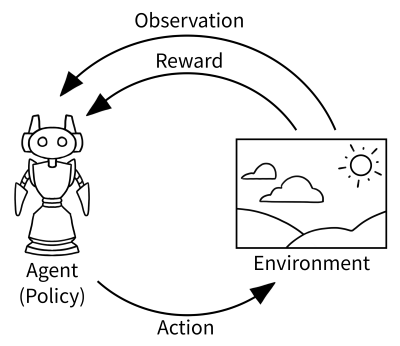

Every environment needs to specify an action space and an observation space. The action space defines the set of possible actions the agent can take, while the observation space defines the format of the data the agent receives from the environment. In our drone environment, the action space is two continuous values representing the thrust of left and right rotors, while the observation space is a continuous vector containing the distance and velocity to the next checkpoint, the distance from the ground, and its remaining battery level.

---

<span style="color:#55ff55;font-weight:bold;font-size:1.5rem;">
    GO
</span>


Now that we have a basic understanding of reinforcement learning, let's dive into the code and see how we can implement this in our custom environment! 

In this workshop we will develop a custom environment for a drone navigation task. The drone must navigate through checkpoints while managing its battery and avoiding crashing into the ground. The score will be calculated based on how many checkpoints the drone collects and how quickly it reaches them. This score will only be used as an evaluation metric, but the reward function will be designed to encourage the drone to collect checkpoints and avoid crashing which may not directly correlate with the score.

We first need to create our custom environment. We will define a class `DroneEnv` that inherits from `gym.Env`. This class will implement the necessary methods for our environment, including `__init__`, `reset`, and `step`.

Feel free to explore the code and understand how the environment is structured. The `step` function is where the main logic of the environment resides, as it processes the agent's actions and returns the new state, reward, and done flag.

In [ ]:
OUTPUT_PATH = "episode.mp4"
MODEL_PATH = "ppo_drone_delivery.zip"
MAX_EPISODE_STEPS = 1200

class DroneEnv(gym.Env):
    def __init__(self):
        '''
        Initializes the DroneEnv class and declares constants used in the env
        '''
        super().__init__()

        self.action_space = self.get_action_space()
        self.observation_space = self.get_observation_space()

        # Environment constants
        self.dt = 1.0 / 60.0
        self.mass = 1.0
        self.I = 0.1
        self.g = 9.81
        self.drone_width = 0.4
        self.max_thrust = 10.0
        self.width = 14.0
        self.height = 10.0
        self.world_screen_width = 720
        self.ui_width = 200
        self.screen_width = self.world_screen_width + self.ui_width
        self.screen_height = 540
        self.scale = self.world_screen_width / self.width
        self.drone_color = (250, 100, 20) # (BGR)
        self.thrust_color = (20, 20, 250) # Red (BGR)
        self.checkpoint_color = (50, 200, 50) # Green (BGR)
        self.battery_base_drain = 1.0 / 10000.0
        self.battery_thrust_drain = 1.0 / 500.0
        self.checkpoint_radius = 0.45
        self.max_steps = MAX_EPISODE_STEPS
        self.ground_thickness = 0.2
        self.drone_half_height = 5.0 / self.scale
        self.drone_ground_y = self.ground_thickness + self.drone_half_height

        self.reset()
    
    def get_action_space(self):
        '''
        The action consists of two continuous values in [-1, 1] representing left and right rotor thrust controls.
        This needs to be defined for the model, and will be scaled to actual thrust values in the step() function.
        '''
        return spaces.Box(low=-1.0, high=1.0, shape=(2,), dtype=np.float32)

    def get_observation_space(self):
        '''
        The observation consists of 11 continuous values.
        The observation() method will return the actual values, 
        but we need to explicitly define the space here for the model ahead of time.
        '''
        return spaces.Box(low=-np.inf, high=np.inf, shape=(11,), dtype=np.float32)

    def reset(self, seed=None, options=None):
        '''
        Resets the environment to an initial state and returns the initial observation.
        '''
        super().reset(seed=seed)

        # Drone state: x, y, vx, vy, angle, angular_vel, battery
        self.pos_x = self.width / 2.0
        self.pos_y = self.height * 0.65
        self.vel_x = 0.0
        self.vel_y = 0.0
        self.angle = 0.0
        self.angular_vel = 0.0
        self.battery = 1.0

        # Checkpoints
        self.checkpoint = None
        self.next_checkpoint_side = 1.0
        self.total_collected = 0
        self.score = 0.0

        self.step_count = 0
        self.drone_ground_collision = False
        self.last_action = [0.0, 0.0]
        self.collected_this_step = 0
        self.last_reward = 0.0
        self.episode_reward = 0.0

        self._spawn_checkpoint()

        return self.observation(), {}

    def observation(self):
        '''
        Returns observation for the current state of the environment.
        '''
        cp_dx, cp_dy = 0.0, 0.0
        cp_dvx, cp_dvy = -self.vel_x, -self.vel_y
        ground_distance = self.pos_y - self.drone_ground_y
        drone_x_relative = self.pos_x - self.width / 2.0

        if self.checkpoint is not None:
            cp_dx = float(self.checkpoint[0] - self.pos_x)
            cp_dy = float(self.checkpoint[1] - self.pos_y)

        return np.array([
            cp_dx, # X position relative to checkpoint
            cp_dy, # Y position relative to checkpoint
            cp_dvx, # X velocity relative to checkpoint
            cp_dvy, # Y velocity relative to checkpoint
            ground_distance, # Distance to ground
            self.vel_x, # X velocity
            self.vel_y, # Y velocity
            self.angle, # Angle
            self.angular_vel, # Angular velocity
            self.battery, # Battery level
            drone_x_relative # X position relative to the world
        ], dtype=np.float32)

    def step(self, action):
        '''
        Performs one step in the environment based on the provided actions.
        '''
        self.step_count += 1

        obs_before = self.observation()

        # Map actions [-1, 1] to thrusts [-max_thrust, max_thrust].
        left_thrust = float(action[0]) * self.max_thrust
        right_thrust = float(action[1]) * self.max_thrust

        # Battery depletion disables thrust; gravity will eventually pull the drone down.
        if self.battery <= 0.0:
            left_thrust = right_thrust = 0.0

        # Save action values for rendering
        self.last_action = [left_thrust, right_thrust]

        total_thrust = left_thrust + right_thrust
        force_x = -total_thrust * math.sin(self.angle)
        force_y = total_thrust * math.cos(self.angle) - self.mass * self.g

        torque = (right_thrust - left_thrust) * (self.drone_width / 2.0)

        self.angular_vel += (torque / self.I) * self.dt
        self.angle += self.angular_vel * self.dt

        self.vel_x += (force_x / self.mass) * self.dt
        self.vel_y += (force_y / self.mass) * self.dt
        self.pos_x += self.vel_x * self.dt
        self.pos_y += self.vel_y * self.dt

        self.drone_ground_collision = False
        if self.pos_y < self.drone_ground_y:
            self.pos_y = self.drone_ground_y
            if self.vel_y < 0.0:
                self.vel_y = 0.0
            self.vel_x = 0.0
            self.drone_ground_collision = True

        thrust_load = (abs(left_thrust) + abs(right_thrust)) / (2.0 * self.max_thrust)
        self.battery -= self.battery_base_drain
        self.battery -= thrust_load * self.battery_thrust_drain
        self.battery = max(0.0, self.battery)

        # Collect checkpoint when within collection radius.
        checkpoints_collected = 0
        if self.checkpoint is not None and math.hypot(
            float(self.checkpoint[0]) - self.pos_x,
            float(self.checkpoint[1]) - self.pos_y,
        ) <= self.checkpoint_radius:
            checkpoints_collected = 1
            self.total_collected += 1
            num_steps = max(1, self.step_count)
            self.score = 1000.0 * self.total_collected + 100000.0 * (self.total_collected / num_steps)
            self.checkpoint = None
        self.collected_this_step = checkpoints_collected
        self._spawn_checkpoint()

        observation = self.observation()

        info = {
            "collected_this_step": self.collected_this_step,
            "total_collected": self.total_collected,
            "score": self.score,
            "collision": self.drone_ground_collision
        }

        reward = self.reward(obs_before, observation, action, info)
        self.last_reward = float(reward)
        self.episode_reward += float(reward)

        terminated = self.drone_ground_collision
        truncated = self.step_count >= self.max_steps

        return observation, reward, terminated, truncated, info

    def reward(self, obs_before, obs_after, action, info):
        '''
        Computes a reward based on the action as well as the observation before and after.
        '''
        return 0 # We'll fill this in later to teach the agent how to navigate
    
    def _spawn_checkpoint(self):
        '''
        Helper method to spawn the checkpoint in the environment.
        '''
        if self.checkpoint is not None:
            return
        for _ in range(64):
            side = self.next_checkpoint_side
            drone_x = float(np.clip(self.pos_x, 0.8, self.width - 0.8))
            y = float(self.np_random.uniform(self.ground_thickness + 1.0, self.height - 0.8))

            if side > 0.0:
                x_min = max(drone_x + 1.0, self.width * 0.55, 0.8)
                x_max = self.width - 0.8
            else:
                x_min = 0.8
                x_max = min(drone_x - 1.0, self.width * 0.45, self.width - 0.8)

            if x_min >= x_max:
                x = x_max if side > 0.0 else x_min
            else:
                x = float(self.np_random.uniform(x_min, x_max))

            self.checkpoint = np.array([x, y], dtype=np.float32)
            self.next_checkpoint_side *= -1.0
            return

    def render(self):
        '''
        Renders the state of the environment and returns an image
        '''
        # Create a white background image
        img = np.ones((self.screen_height, self.screen_width, 3), dtype=np.uint8) * 255

        panel_x = self.world_screen_width + 25
        panel_top = 50
        panel_width = 110
        bar_height = 18
        bar_gap = 50

        def draw_bar(y, label, value, color):
            value = float(np.clip(value, 0.0, 1.0))
            cv2.rectangle(img, (panel_x, y), (panel_x + panel_width, y + bar_height), (210, 210, 210), 1)
            fill_width = int(panel_width * value)
            if fill_width > 0:
                cv2.rectangle(img, (panel_x, y), (panel_x + fill_width, y + bar_height), color, -1)
            cv2.putText(img, label, (panel_x, y - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 0), 1, cv2.LINE_AA)

        # Transform functions
        def to_pixels(x, y):
            return int(x * self.scale), int(self.screen_height - y * self.scale)

        # Draw ground strip
        ground_top = to_pixels(0.0, self.ground_thickness)[1]
        cv2.rectangle(img, (0, ground_top), (self.screen_width, self.screen_height), (225, 225, 225), -1)
        cv2.line(img, (0, ground_top), (self.screen_width, ground_top), (170, 170, 170), 2)

        # Draw checkpoints.
        cp_radius_px = int(self.checkpoint_radius * self.scale)
        if self.checkpoint is not None:
            cp_px = to_pixels(float(self.checkpoint[0]), float(self.checkpoint[1]))
            cv2.circle(img, cp_px, cp_radius_px, self.checkpoint_color, -1)
            cv2.circle(img, cp_px, cp_radius_px, (0, 0, 0), 1)

        # Draw Drone
        drone_px = to_pixels(self.pos_x, self.pos_y)

        half_w = int(self.drone_width / 2.0 * self.scale)
        h = 5
        pts = np.array([[-half_w, -h], [half_w, -h], [half_w, h], [-half_w, h]], dtype=np.int32)

        cos_a = math.cos(-self.angle)
        sin_a = math.sin(-self.angle)

        def rotate_local(point):
            rx = point[0] * cos_a - point[1] * sin_a
            ry = point[0] * sin_a + point[1] * cos_a
            return int(rx + drone_px[0]), int(ry + drone_px[1])

        rotated_pts = [rotate_local(p) for p in pts]

        rotated_pts = np.array(rotated_pts, dtype=np.int32)
        cv2.fillPoly(img, [rotated_pts], self.drone_color)

        # Draw thrust lines.
        left_t, right_t = self.last_action
        for thrust, x_pos in ((left_t, -half_w), (right_t, half_w)):
            if abs(thrust) <= 1e-6:
                continue
            sign = 1.0 if thrust > 0.0 else -1.0
            length = 50.0 * (abs(thrust) / self.max_thrust)
            start = np.array([x_pos, h], dtype=np.float32)
            end = np.array([x_pos, h + sign * length], dtype=np.float32)
            cv2.line(img, rotate_local(start), rotate_local(end), self.thrust_color, 2)

        average_thrust = (abs(left_t) + abs(right_t)) / (2.0 * self.max_thrust)

        # Side panel indicators.
        draw_bar(panel_top, "Battery", self.battery, self.checkpoint_color)
        draw_bar(panel_top + bar_gap, "Thrust", average_thrust, self.thrust_color)
        cv2.putText(img, f"Score: {self.score:.0f}", (panel_x - 10, panel_top + bar_gap * 2 + 2),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1, cv2.LINE_AA)
        cv2.putText(img, f"Checkpoints: {self.total_collected}", (panel_x - 10, panel_top + bar_gap * 3 + 2),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1, cv2.LINE_AA)
        cv2.putText(img, f"Step: {self.step_count}", (panel_x - 10, panel_top + bar_gap * 4 + 2),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1, cv2.LINE_AA)
        cv2.putText(img, f"Reward: {self.last_reward:.2f}", (panel_x - 10, panel_top + bar_gap * 5 + 2),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1, cv2.LINE_AA)
        cv2.putText(img, f"Total Reward: {self.episode_reward:.2f}", (panel_x - 10, panel_top + bar_gap * 6 + 2),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1, cv2.LINE_AA)

        return img

    def close(self):
        pass


<span style="color:#ff5555;font-weight:bold;font-size:1.5rem;">
    STOP
</span>

... or keep going if you want to work ahead.

---

**How do we train and test our agent?**

Next we need to create our training loop. We will use [Stable Baselines3](https://www.geeksforgeeks.org/deep-learning/stable-baselines3/), a popular library for reinforcement learning, to train our agent. 

We will create an instance of our `DroneEnv` environment and then use the a training algorithm to allow our agent to learn. 

Since we have a continuous action space, we will use the Proximal Policy Optimization ([PPO](https://www.geeksforgeeks.org/machine-learning/a-brief-introduction-to-proximal-policy-optimization/)) algorithm, which is well-suited for continuous control tasks.

The training loop will involve calling the `learn` method of the PPO model, which will handle the interaction with the environment and the learning process.

---

<span style="color:#55ff55;font-weight:bold;font-size:1.5rem;">
    GO
</span>

Run this code to register our environment for the Stable Baselines3 library, and then create the function to train our agent:


In [ ]:
# We need to register the environment so that it can be created with gym.make()
register(
    id="DroneDelivery-v0",
    entry_point="__main__:DroneEnv",
    max_episode_steps=MAX_EPISODE_STEPS,
)

In [ ]:
def train(timesteps):
    env = gym.make("DroneDelivery-v0")

    model_path = Path(MODEL_PATH)

    try:
        model = PPO.load(str(model_path), env=env)
        # model.learning_rate = 3e-4
        # You can adjust hyperparameters here if you want to try other values
    except:
        model = PPO("MlpPolicy", env, verbose=1, learning_rate=3e-4, stats_window_size=10)

    if timesteps > 0:
        model.learn(total_timesteps=timesteps, reset_num_timesteps=False)
        print(f"Training for {timesteps} timesteps completed.")
    model.save(MODEL_PATH)
    print(f"Model saved to {MODEL_PATH}.")

Before we start training, run this cell to create a new model and create a function to evaluate the performance of our trained agent.

In [ ]:
train(0)

Now that we have a model, we can evaluate its performance by running it in the environment and observing how well it navigates through the checkpoints.

Run this code to create a function to run our trained agent in the environment and visualize its performance:

In [ ]:
def eval():
    print("Starting evaluation...")
    env = gym.make("DroneDelivery-v0")
    model = PPO.load(MODEL_PATH)

    observation, _ = env.reset()
    terminated = False
    truncated = False
    total_reward = 0.0
    step_count = 0
    total_collected = 0
    score = 0

    frame = env.render()
    if frame is None:
        env.close()
        raise RuntimeError("Environment returned no frame.")

    fps = int(60)
    output_file = Path(OUTPUT_PATH)
    output_file.parent.mkdir(parents=True, exist_ok=True)
    output_path = str(output_file.resolve())
    writer = imageio.get_writer(output_path, fps=fps, macro_block_size=1, codec="libx264")

    try:
        while not (terminated or truncated):
            action, _ = model.predict(observation, deterministic=True)
            observation, reward, terminated, truncated, info = env.step(action)
            total_reward += float(reward)
            step_count += 1
            total_collected = info.get("total_collected", total_collected)
            score = info.get("score", score)

            frame = env.render()
            if frame is None:
                break
            writer.append_data(frame)
    finally:
        writer.close()
        env.close()

    print("Evaluation complete.")
    print(f"Episode steps:          {step_count}")
    print(f"Episode reward:         {total_reward:.2f}")
    print(f"Collected checkpoints:  {total_collected}")
    print(f"Score:                  {score}")

    display(Video(OUTPUT_PATH, embed=True, html_attributes="loop autoplay muted", width=600))

Let's run the evaluation and see what our agent does before training.

In [ ]:
eval()

<span style="color:#ff5555;font-weight:bold;font-size:1.5rem;">
    STOP
</span>

... or keep going if you want to work ahead.

---

**How do we teach our agent to learn?**

Look like our agent hasn't learned anything yet, which is expected since we haven't trained it. Before we can train it, we need to define a reward function that will provide feedback to the agent based on its actions and the resulting state of the environment.

Let's start by implementing a basic reward function to help teach the agent to hover in the air without crashing. Once it learns how to do that, we can start adding more complex rewards to encourage it to navigate through the checkpoints and manage its battery effectively.

The agent will learn to perform actions that maximize the reward it receives. By shaping the reward function appropriately, we can guide the agent towards learning the desired behavior of navigating through checkpoints while managing its battery and avoiding crashes.


---

<span style="color:#55ff55;font-weight:bold;font-size:1.5rem;">
    GO
</span>

Run this code to implement a basic reward function that encourages the agent to hover without crashing:

In [ ]:
def basic_reward(self, obs_before, obs_after, action, info):
    '''
    Computes a reward based on the action as well as the observation before and after.
    '''
    angel_vel_after = float(obs_after[8])
    ground_distance_after = float(obs_after[4])
    ground_distance_before = float(obs_before[4])
    ground_distance_change = (ground_distance_after - ground_distance_before)

    reward = 0.0

    reward -= 1.0 * abs(ground_distance_change * 60) # Large penalty for changes in altitude to encourage hovering.
    reward -= 1.0 * abs(angel_vel_after) # Large penalty for angular velocity to encourage stable flight.

    return reward

DroneEnv.reward = basic_reward

Now that we have a basic reward function implemented, we can start training our agent and see how it learns to fly.

Let's train it for 100,000 timesteps and see how it performs. The `ep_len_mean` (average episode length) and `ep_rew_mean` (average episode reward) will probably stay quite low at first, but as the agent learns to hover and avoid crashing, we should see it start to improve over time.

You might need to keep training it a few times to see significant improvements, but once it starts learns to hover, feel free to move on to implementing more complex rewards to encourage it to navigate through the checkpoints and manage its battery effectively!

In [ ]:
train(100_000) # You can re-run this cell to continue to train the model from where it left off

Now that we've trained our agent, let's evaluate its performance again and see how it has improved.

In [ ]:
eval() # You can re-run this cell to see how the agent performs in the environment

<span style="color:#ff5555;font-weight:bold;font-size:1.5rem;">
    STOP
</span>

... or keep going if you want to work ahead.

---

**How do we encourage our agent to learn more complex behaviors?**

Look's like we've trained our agent to not immediately crash into the ground, so now we can start adding more complex rewards to encourage it to navigate through the checkpoints.

This new reward function removed the penalty for changing altitude, which should allow the agent to learn to move up and down more freely. It also added a reward for moving toward the checkpoint, which should encourage the agent to learn to navigate toward the checkpoints instead of just hovering in place.

Finally, it added a large reward for collecting a checkpoint, which should encourage the agent to actually collect the checkpoints instead of just flying around them.

---

<span style="color:#55ff55;font-weight:bold;font-size:1.5rem;">
    GO
</span>

Run this code to implement the new reward function that encourages the agent to navigate through the checkpoints and manage its battery effectively:

In [ ]:
def complex_reward(self, obs_before, obs_after, action, info):
    '''
    Computes a reward based on the action as well as the observation before and after.
    '''
    battery_after = float(obs_after[9])
    battery_before = float(obs_before[9])
    angle_after = float(obs_after[7])
    collision = info.get("collision", False)
    cp_dx_after = float(obs_after[0])
    cp_dy_after = float(obs_after[1])
    cp_dvx_after = float(obs_after[2])
    cp_dvy_after = float(obs_after[3])
    dist_after = math.hypot(cp_dx_after, cp_dy_after)
    closing_speed = -((cp_dx_after * cp_dvx_after + cp_dy_after * cp_dvy_after)
        / (dist_after + 1e-6))
    collected_this_step = info.get("collected_this_step", 0)

    reward = 0.0

    reward -= 0.01 * (battery_before - battery_after) # Small penalty for battery usage to encourage efficiency.
    reward -= 0.003 * abs(angle_after) # Small penalty for tilting to encourage stable flight.
    if not collision:
        reward += 0.001 # Small reward for staying in the air to encourage flight.

    if collision and battery_after > 0.0:
        reward -= 1000.0 # Large penalty for crashing into the ground if battery is not depleted
    
    reward += 1.0 * closing_speed # Reward for moving toward the checkpoint

    reward += 100.0 * float(collected_this_step) # Large reward for collecting a checkpoint

    return reward

DroneEnv.reward = complex_reward

Now, let's continue to train our agent with this new reward function and see how it learns to navigate through the checkpoints!

This may take a while to see significant improvements, so you might want to keep retraining it a few times. Once the agent finally learns to collect the first checkpoint, it should start to learn much faster. 

In [ ]:
train(100_000) # You can re-run this cell to continue to train the model from where it left off

In [ ]:
eval() # You can re-run this cell to see how the agent performs in the environment

<span style="color:#ff5555;font-weight:bold;font-size:1.5rem;">
    STOP
</span>

... or keep going if you want to work ahead.

---

**How do we further encourage our agent to learn even better behaviors?**

After running the training a few times and checking the evaluation, you should start to see the agent learning to navigate through the checkpoints and manage its battery effectively.

We can keep adjusting the reward function to encourage even better performance. For example, we could add a penalty for running out of battery, or try removing some of the smaller rewards now that the agent has learned how to fly around.

Try tweaking the `complex_reward` function above further to see if you can encourage even better performance! Also, if you're comfortable you can try adjusting the hyperparameters of the PPO algorithm in the `train` function to see if you can speed up the learning process.

---

<span style="color:#55ff55;font-weight:bold;font-size:1.5rem;">
    GO
</span>

Keep tweaking the reward function and training the agent to see if you can get it to perform even better! Try to get it to collect as many checkpoints as possible while managing its battery and avoiding crashes. You could try things like adding a penalty for running out of battery, or try removing some of the smaller rewards now that the agent has learned how to fly around. There are many possibilities for shaping the reward function to encourage different behaviors, so feel free to experiment and see what works best!